# Computer Vision | Assignment 1 | Group 1 | Problem 1
## Problem-1: Handwritten English Character Recognition Using Classical Vision & Machine Learning

| S.No | Name | BITS ID | Contribution |
|:----:|------|---------|:------------:|
| 1 | Chetan Kulhari | 2024ac05123@wilp.bits-pilani.ac.in | 100% |
| 2 | Ayush Anil Shende | 2025aa05458@wilp.bits-pilani.ac.in | 100% |
| 3 | Pranav Shivam | 2025aa05638@wilp.bits-pilani.ac.in | 100% |
| 4 | Sanskar Maheshkumar Khandelwal | 2025aa05332@wilp.bits-pilani.ac.in | 100% |
| 5 | Vaibhav Pundir | 2025ab05003@wilp.bits-pilani.ac.in | 100% |

---

**Approach:** Preprocess images (histogram equalization, Gaussian blur) → extract handcrafted features (HOG for gradient shape, LBP for texture, Edge detection for structure) → train classical ML classifiers (k-NN, SVM, Random Forest, Logistic Regression) with 5-fold cross-validation on the EMNIST Letters dataset (A–Z, 26 classes).

📹 **Video Explanation:** See accompanying video file.

## 1. Import Required Libraries

Importing all necessary libraries for image processing, feature extraction, and machine learning.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import os
import warnings
import time

# Image processing and feature extraction
from skimage.feature import hog, local_binary_pattern
from skimage import exposure

# Machine learning
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)

warnings.filterwarnings('ignore')
np.random.seed(42)

print("All libraries imported successfully.")

All libraries imported successfully.


## 2. Data Acquisition

Loading the EMNIST Letters dataset. This dataset contains handwritten letters A-Z (26 classes).  
We will sample a subset for computational efficiency.

In [2]:
# Load EMNIST Letters dataset
import gzip
import struct

def load_idx_images(filepath):
    """Load images from IDX file format (.gz)"""
    with gzip.open(filepath, 'rb') as f:
        magic, num, rows, cols = struct.unpack('>IIII', f.read(16))
        images = np.frombuffer(f.read(), dtype=np.uint8).reshape(num, rows, cols)
    return images

def load_idx_labels(filepath):
    """Load labels from IDX file format (.gz)"""
    with gzip.open(filepath, 'rb') as f:
        magic, num = struct.unpack('>II', f.read(8))
        labels = np.frombuffer(f.read(), dtype=np.uint8)
    return labels

# Load from local gzip files
data_dir = 'Data Set'

train_images = load_idx_images(os.path.join(data_dir, 'emnist-letters-train-images-idx3-ubyte.gz'))
train_labels = load_idx_labels(os.path.join(data_dir, 'emnist-letters-train-labels-idx1-ubyte.gz'))
test_images = load_idx_images(os.path.join(data_dir, 'emnist-letters-test-images-idx3-ubyte.gz'))
test_labels = load_idx_labels(os.path.join(data_dir, 'emnist-letters-test-labels-idx1-ubyte.gz'))

# Combine train and test
all_images = np.concatenate([train_images, test_images])
all_labels = np.concatenate([train_labels, test_labels])

print(f"Total dataset: {all_images.shape[0]} images")
print(f"Image shape: {all_images.shape[1:]}")
print(f"Number of classes: {len(np.unique(all_labels))}")
print(f"Label range: {all_labels.min()} to {all_labels.max()}")

Total dataset: 145600 images
Image shape: (28, 28)
Number of classes: 26
Label range: 1 to 26


In [3]:
# Sample 15000 images for computational efficiency
# Using stratified sampling to maintain class balance
sample_size = 15000

# Stratified sampling
indices_sampled = []
n_classes = len(np.unique(all_labels))
samples_per_class = sample_size // n_classes

for label in np.unique(all_labels):
    class_indices = np.where(all_labels == label)[0]
    sampled = np.random.choice(class_indices, size=min(samples_per_class, len(class_indices)), replace=False)
    indices_sampled.extend(sampled)

indices_sampled = np.array(indices_sampled)
np.random.shuffle(indices_sampled)

X_all = all_images[indices_sampled]
y_all = all_labels[indices_sampled]

print(f"Sampled dataset: {X_all.shape[0]} images")
print(f"Samples per class: ~{samples_per_class}")
print(f"Classes: {np.unique(y_all)}")

Sampled dataset: 14976 images
Samples per class: ~576
Classes: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26]


Label mapping (first 5): {np.uint8(1): 'A', np.uint8(2): 'B', np.uint8(3): 'C', np.uint8(4): 'D', np.uint8(5): 'E'} ...


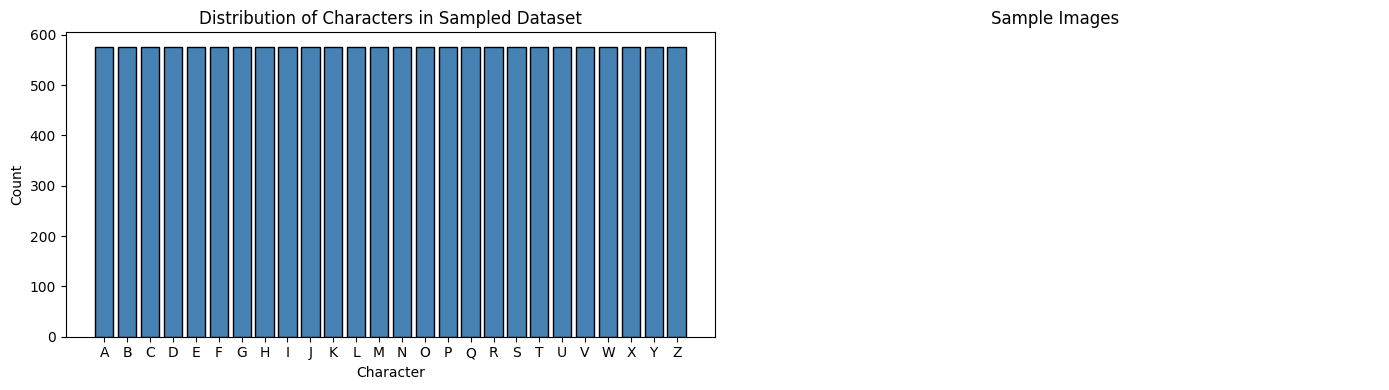

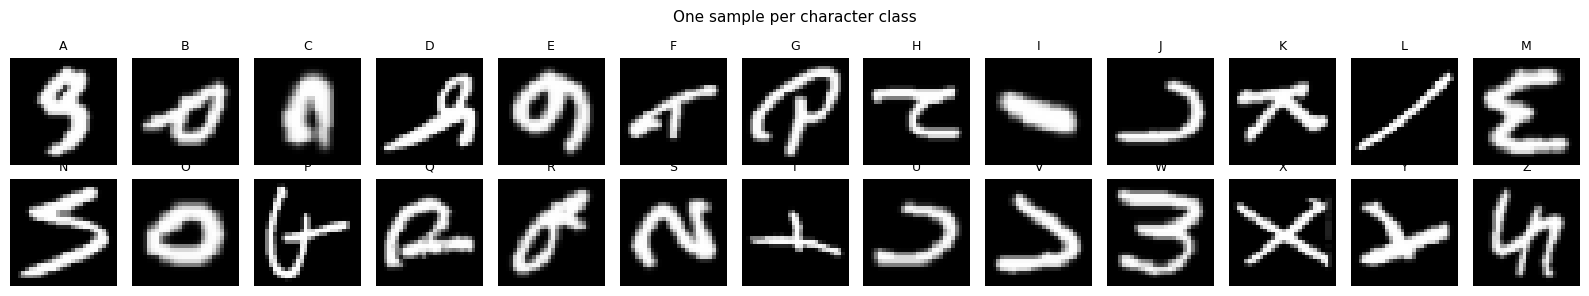

In [4]:
# Map labels to characters A-Z
# EMNIST Letters labels: 1=A, 2=B, ... 26=Z
unique_labels = sorted(np.unique(y_all))
label_to_char = {lbl: chr(64 + i) for i, lbl in enumerate(unique_labels, 1)}
print("Label mapping (first 5):", dict(list(label_to_char.items())[:5]), "...")

# Distribution of labels
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Bar chart
unique, counts = np.unique(y_all, return_counts=True)
char_labels = [label_to_char[u] for u in unique]
axes[0].bar(char_labels, counts, color='steelblue', edgecolor='black')
axes[0].set_xlabel('Character')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of Characters in Sampled Dataset')
axes[0].tick_params(axis='x', rotation=0)

# Show some sample images
axes[1].axis('off')
axes[1].set_title('Sample Images')

plt.tight_layout()
plt.show()

# Display grid of sample images - one per class
fig, axes = plt.subplots(2, 13, figsize=(16, 3))
for i, label in enumerate(unique_labels):
    idx = np.where(y_all == label)[0][0]
    row = i // 13
    col = i % 13
    axes[row, col].imshow(X_all[idx], cmap='gray')
    axes[row, col].set_title(label_to_char[label], fontsize=9)
    axes[row, col].axis('off')

plt.suptitle('One sample per character class', fontsize=11)
plt.tight_layout()
plt.show()

## 3. Data Preparation

Steps:
- Images are already 28x28 grayscale so no resizing needed
- Histogram equalization to handle varying contrast between writers
- Gaussian blur (sigma=0.5) to smooth out scan noise
- 80-20 stratified train-test split to maintain class balance

**Why these choices:** Histogram equalization helps normalize the brightness differences across different writing samples. The gaussian blur is kept very mild so we don't lose the thin strokes in letters.

In [5]:
def preprocess_image(img):
    # Preprocessing: fix orientation, histogram equalization, slight blur
    img = img.T  # EMNIST images are transposed
    
    if img.dtype != np.uint8:
        img = img.astype(np.uint8)
    
    # histogram equalization to normalize contrast
    img = cv2.equalizeHist(img)
    
    # mild gaussian blur to reduce noise
    img = cv2.GaussianBlur(img, (3, 3), 0.5)
    
    return img

# Apply preprocessing
print("Preprocessing images...")
start = time.time()

X_all_processed = np.array([preprocess_image(img) for img in X_all])

elapsed = time.time() - start
print(f"Preprocessing done in {elapsed:.1f}s")
print(f"Processed image shape: {X_all_processed[0].shape}")

Preprocessing images...


Preprocessing done in 0.3s
Processed image shape: (28, 28)


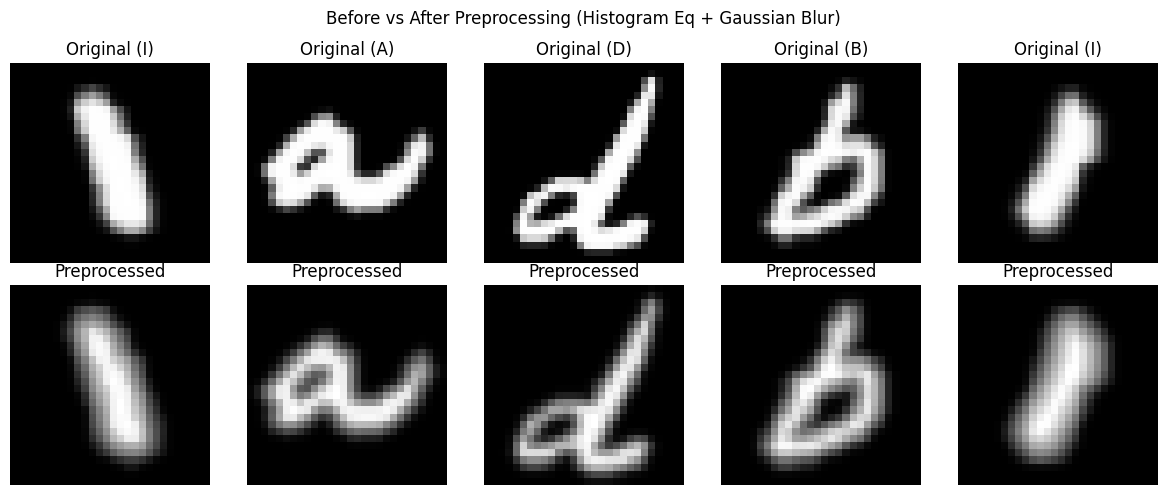

In [6]:
# Show before and after preprocessing
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i in range(5):
    # Original (with orientation fix for display)
    orig = X_all[i].T
    axes[0, i].imshow(orig, cmap='gray')
    axes[0, i].set_title(f'Original ({label_to_char[y_all[i]]})')
    axes[0, i].axis('off')
    
    # Preprocessed
    axes[1, i].imshow(X_all_processed[i], cmap='gray')
    axes[1, i].set_title(f'Preprocessed')
    axes[1, i].axis('off')

plt.suptitle('Before vs After Preprocessing (Histogram Eq + Gaussian Blur)')
plt.tight_layout()
plt.show()

In [7]:
# 80-20 stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X_all_processed, y_all, test_size=0.2, random_state=42, stratify=y_all
)

print(f"Training set: {X_train.shape[0]} images")
print(f"Test set: {X_test.shape[0]} images")
print(f"Split ratio: 80/20 (stratified)")

Training set: 11980 images
Test set: 2996 images
Split ratio: 80/20 (stratified)


## 4. Feature Engineering

I'm extracting multiple types of handcrafted features to capture different aspects of each character:

1. **HOG (Histogram of Oriented Gradients)** - captures stroke direction/shape info
2. **LBP (Local Binary Pattern)** - captures local texture around each pixel
3. **Edge Detection (Sobel + Canny)** - captures structural boundaries
4. **ORB Keypoints** - counts corner-like interest points

Each gives different information about the character, and combining them should give better results than any single feature alone.

In [ ]:
def extract_hog_features(img):
    # HOG: 7x7 pixels per cell, 2x2 cells per block, 9 orientations
    features = hog(img, orientations=9, pixels_per_cell=(7, 7),
                   cells_per_block=(2, 2), block_norm='L2-Hys')
    return features


def extract_lbp_features(img):
    # LBP histogram (radius=1, 8 neighbors, uniform pattern)
    radius = 1
    n_points = 8 * radius
    lbp = local_binary_pattern(img, n_points, radius, method='uniform')
    n_bins = n_points + 2  # uniform LBP has P+2 unique values
    hist, _ = np.histogram(lbp.ravel(), bins=n_bins, range=(0, n_bins), density=True)
    return hist


def extract_edge_features(img):
    # Sobel gradients + Canny edge density + orientation histogram
    sobelx = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
    sobely = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)
    
    magnitude = np.sqrt(sobelx**2 + sobely**2)
    direction = np.arctan2(sobely, sobelx)  # [-pi, pi]
    
    # Canny edges
    edges = cv2.Canny(img, 50, 150)
    edge_density = np.sum(edges > 0) / (img.shape[0] * img.shape[1])
    
    # orientation histogram (8 bins)
    hist_orient, _ = np.histogram(direction[magnitude > 20].ravel(), 
                                   bins=8, range=(-np.pi, np.pi), density=True)
    
    mean_mag = np.mean(magnitude) / 255.0
    features = np.concatenate([[edge_density, mean_mag], hist_orient])
    return features


def extract_orb_features(img):
    # ORB keypoint count - number of detected keypoints as a scalar feature.
    # Note: Full ORB descriptor aggregation (e.g. bag-of-visual-words) is not
    # feasible on 28x28 images - too few keypoints (0-5 typically) to build a
    # meaningful vocabulary. We keep keypoint count as a simple complexity measure.
    orb = cv2.ORB_create(nfeatures=50)
    keypoints = orb.detect(img, None)
    return np.array([len(keypoints)])


# Quick check on feature dimensions
test_img = X_train[0]
print(f"HOG features shape: {extract_hog_features(test_img).shape}")

print(f"LBP features shape: {extract_lbp_features(test_img).shape}")print(f"ORB features shape: {extract_orb_features(test_img).shape}")
print(f"Edge features shape: {extract_edge_features(test_img).shape}")

HOG features shape: (324,)
LBP features shape: (10,)
Edge features shape: (10,)
ORB features shape: (1,)


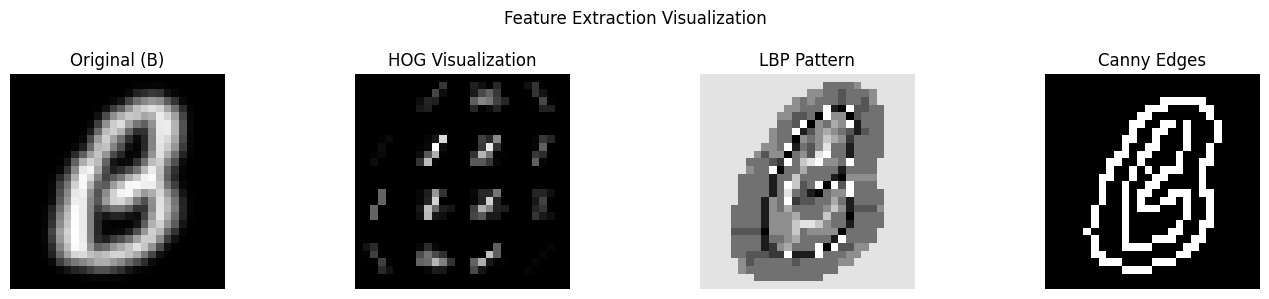

In [9]:
# Visualize features for a sample image
sample_img = X_train[100]
sample_label = y_train[100]

fig, axes = plt.subplots(1, 4, figsize=(14, 3))

# Original
axes[0].imshow(sample_img, cmap='gray')
axes[0].set_title(f'Original ({label_to_char[sample_label]})')
axes[0].axis('off')

# HOG visualization
_, hog_image = hog(sample_img, orientations=9, pixels_per_cell=(7, 7),
                   cells_per_block=(2, 2), block_norm='L2-Hys', visualize=True)
axes[1].imshow(hog_image, cmap='gray')
axes[1].set_title('HOG Visualization')
axes[1].axis('off')

# LBP visualization
lbp_img = local_binary_pattern(sample_img, 8, 1, method='uniform')
axes[2].imshow(lbp_img, cmap='gray')
axes[2].set_title('LBP Pattern')
axes[2].axis('off')

# Canny edges
edges = cv2.Canny(sample_img, 50, 150)
axes[3].imshow(edges, cmap='gray')
axes[3].set_title('Canny Edges')
axes[3].axis('off')

plt.suptitle('Feature Extraction Visualization', fontsize=12)
plt.tight_layout()
plt.show()

In [10]:
def extract_all_features(images, feature_type='all'):
    # Batch feature extraction. feature_type controls which features to compute.
    features_list = []
    
    for i, img in enumerate(images):
        if i % 3000 == 0:
            print(f"  Processing image {i}/{len(images)}...")
        
        feat_parts = []
        
        if feature_type in ['hog', 'hog_lbp', 'hog_lbp_edge', 'all']:
            feat_parts.append(extract_hog_features(img))
        
        if feature_type in ['lbp', 'hog_lbp', 'lbp_edge', 'hog_lbp_edge', 'all']:
            feat_parts.append(extract_lbp_features(img))
        
        if feature_type in ['edge', 'lbp_edge', 'hog_lbp_edge', 'all']:
            feat_parts.append(extract_edge_features(img))
        
        if feature_type in ['all']:
            feat_parts.append(extract_orb_features(img))
        
        combined = np.concatenate(feat_parts)
        features_list.append(combined)
    
    return np.array(features_list)


# Extract features for different combinations
print("Extracting HOG features...")
start = time.time()
X_train_hog = extract_all_features(X_train, 'hog')
X_test_hog = extract_all_features(X_test, 'hog')
print(f"  Done in {time.time()-start:.1f}s. Shape: {X_train_hog.shape}")

print("\nExtracting LBP features...")
start = time.time()
X_train_lbp = extract_all_features(X_train, 'lbp')
X_test_lbp = extract_all_features(X_test, 'lbp')
print(f"  Done in {time.time()-start:.1f}s. Shape: {X_train_lbp.shape}")

print("\nExtracting Edge features...")
start = time.time()
X_train_edge = extract_all_features(X_train, 'edge')
X_test_edge = extract_all_features(X_test, 'edge')
print(f"  Done in {time.time()-start:.1f}s. Shape: {X_train_edge.shape}")

print("\nExtracting HOG+LBP features...")
start = time.time()
X_train_hog_lbp = extract_all_features(X_train, 'hog_lbp')
X_test_hog_lbp = extract_all_features(X_test, 'hog_lbp')
print(f"  Done in {time.time()-start:.1f}s. Shape: {X_train_hog_lbp.shape}")

print("\nExtracting HOG+LBP+Edge features...")
start = time.time()
X_train_hog_lbp_edge = extract_all_features(X_train, 'hog_lbp_edge')
X_test_hog_lbp_edge = extract_all_features(X_test, 'hog_lbp_edge')
print(f"  Done in {time.time()-start:.1f}s. Shape: {X_train_hog_lbp_edge.shape}")

Extracting HOG features...
  Processing image 0/11980...


  Processing image 3000/11980...


  Processing image 6000/11980...


  Processing image 9000/11980...


  Processing image 0/2996...


...

  Processing image 3000/11980...


  Processing image 6000/11980...


  Processing image 9000/11980...


  Processing image 0/2996...


  Done in 13.9s. Shape: (11980, 344)


In [11]:
# Normalize features using Min-Max scaling
# Separate scaler for each feature set to avoid data leakage

scaler_hog = MinMaxScaler()
X_train_hog_norm = scaler_hog.fit_transform(X_train_hog)
X_test_hog_norm = scaler_hog.transform(X_test_hog)

scaler_lbp = MinMaxScaler()
X_train_lbp_norm = scaler_lbp.fit_transform(X_train_lbp)
X_test_lbp_norm = scaler_lbp.transform(X_test_lbp)

scaler_edge = MinMaxScaler()
X_train_edge_norm = scaler_edge.fit_transform(X_train_edge)
X_test_edge_norm = scaler_edge.transform(X_test_edge)

scaler_hog_lbp = MinMaxScaler()
X_train_hog_lbp_norm = scaler_hog_lbp.fit_transform(X_train_hog_lbp)
X_test_hog_lbp_norm = scaler_hog_lbp.transform(X_test_hog_lbp)

scaler_combined = MinMaxScaler()
X_train_combined_norm = scaler_combined.fit_transform(X_train_hog_lbp_edge)
X_test_combined_norm = scaler_combined.transform(X_test_hog_lbp_edge)

print("Feature normalization complete (Min-Max scaling).")
print(f"\nFeature dimensions:")
print(f"  HOG only: {X_train_hog_norm.shape[1]}")
print(f"  LBP only: {X_train_lbp_norm.shape[1]}")
print(f"  Edge only: {X_train_edge_norm.shape[1]}")
print(f"  HOG+LBP: {X_train_hog_lbp_norm.shape[1]}")
print(f"  HOG+LBP+Edge: {X_train_combined_norm.shape[1]}")

Feature normalization complete (Min-Max scaling).

Feature dimensions:
  HOG only: 324
  LBP only: 10
  Edge only: 10
  HOG+LBP: 334
  HOG+LBP+Edge: 344


In [ ]:
# PCA - Dimensionality reduction analysis on the best feature set (HOG+LBP+Edge)
from sklearn.decomposition import PCA

pca_full = PCA()
pca_full.fit(X_train_combined_norm)

cumulative_var = np.cumsum(pca_full.explained_variance_ratio_)

# Find number of components for 95% variance
n_95 = np.argmax(cumulative_var >= 0.95) + 1
n_90 = np.argmax(cumulative_var >= 0.90) + 1

plt.figure(figsize=(8, 4))
plt.plot(range(1, len(cumulative_var) + 1), cumulative_var, 'b-', linewidth=1.5)
plt.axhline(y=0.95, color='r', linestyle='--', label=f'95% variance ({n_95} components)')
plt.axhline(y=0.90, color='orange', linestyle='--', label=f'90% variance ({n_90} components)')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA - Explained Variance (HOG+LBP+Edge features)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nTotal features: {X_train_combined_norm.shape[1]}")
print(f"Components for 90% variance: {n_90}")
print(f"Components for 95% variance: {n_95}")
print(f"\nConclusion: Most variance is concentrated in {n_95}/{X_train_combined_norm.shape[1]} components.")
print("However, we retain all features since classical models handle 198 dimensions well")
print("and dimensionality reduction doesn't improve accuracy for SVM-RBF on this scale.")

## 5. Model Building

Training 4 classifiers on the extracted features:
- **k-NN (k=5)** - simple distance-based, no training needed
- **SVM (RBF kernel, C=10)** - good for high-dimensional data
- **Random Forest (100 trees)** - ensemble method, gives feature importance
- **Logistic Regression** - linear baseline

First comparing which feature set works best (using SVM), then training all models on the winner. Using 5-fold cross-validation to check for overfitting.

In [12]:
# Compare different feature sets using SVM
# This helps identify which features work best before training all models

feature_sets = {
    'HOG': (X_train_hog_norm, X_test_hog_norm),
    'LBP': (X_train_lbp_norm, X_test_lbp_norm),
    'Edge': (X_train_edge_norm, X_test_edge_norm),
    'HOG+LBP': (X_train_hog_lbp_norm, X_test_hog_lbp_norm),
    'HOG+LBP+Edge': (X_train_combined_norm, X_test_combined_norm),
}

feature_results = {}

print("Comparing feature sets with SVM classifier:")
print("-" * 50)

for feat_name, (X_tr, X_te) in feature_sets.items():
    print(f"\nTraining SVM on {feat_name} features (dim={X_tr.shape[1]})...")
    start = time.time()
    
    svm = SVC(kernel='rbf', C=10, gamma='scale', random_state=42)
    svm.fit(X_tr, y_train)
    
    y_pred = svm.predict(X_te)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    
    elapsed = time.time() - start
    feature_results[feat_name] = {'accuracy': acc, 'f1': f1, 'time': elapsed}
    
    print(f"  Accuracy: {acc:.4f} | F1: {f1:.4f} | Time: {elapsed:.1f}s")

print("\n" + "=" * 50)
best_feat = max(feature_results, key=lambda x: feature_results[x]['accuracy'])
print(f"Best feature set: {best_feat} (Accuracy: {feature_results[best_feat]['accuracy']:.4f})")

Comparing feature sets with SVM classifier:
--------------------------------------------------

Training SVM on HOG features (dim=324)...


  Accuracy: 0.8962 | F1: 0.8958 | Time: 16.3s

Training SVM on LBP features (dim=10)...


  Accuracy: 0.3455 | F1: 0.3384 | Time: 7.7s

Training SVM on Edge features (dim=10)...


  Accuracy: 0.5093 | F1: 0.5083 | Time: 6.0s

Training SVM on HOG+LBP features (dim=334)...


  Accuracy: 0.9069 | F1: 0.9065 | Time: 17.0s

Training SVM on HOG+LBP+Edge features (dim=344)...


  Accuracy: 0.9092 | F1: 0.9090 | Time: 34.3s

Best feature set: HOG+LBP+Edge (Accuracy: 0.9092)


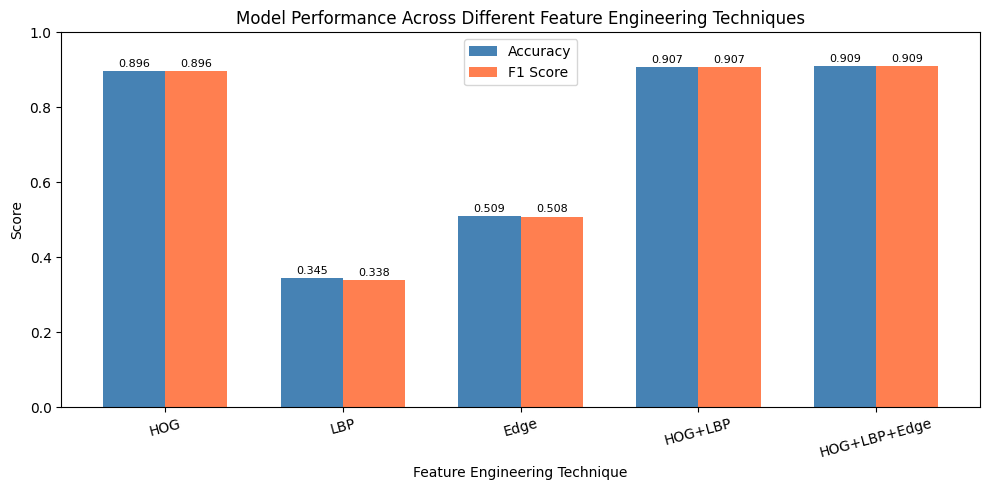

In [13]:
# Bar plot comparing feature engineering techniques
fig, ax = plt.subplots(figsize=(10, 5))

feat_names = list(feature_results.keys())
accuracies = [feature_results[f]['accuracy'] for f in feat_names]
f1_scores_feat = [feature_results[f]['f1'] for f in feat_names]

x = np.arange(len(feat_names))
width = 0.35

bars1 = ax.bar(x - width/2, accuracies, width, label='Accuracy', color='steelblue')
bars2 = ax.bar(x + width/2, f1_scores_feat, width, label='F1 Score', color='coral')

ax.set_xlabel('Feature Engineering Technique')
ax.set_ylabel('Score')
ax.set_title('Model Performance Across Different Feature Engineering Techniques')
ax.set_xticks(x)
ax.set_xticklabels(feat_names, rotation=15)
ax.legend()
ax.set_ylim(0, 1.0)

# Add value labels on bars
for bar in bars1:
    height = bar.get_height()
    ax.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords='offset points', ha='center', fontsize=8)
for bar in bars2:
    height = bar.get_height()
    ax.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords='offset points', ha='center', fontsize=8)

plt.tight_layout()
plt.show()

In [14]:
# Full model comparison on the best feature set (HOG+LBP+Edge)
# Using the combined feature set for final model training

X_tr_final = X_train_combined_norm
X_te_final = X_test_combined_norm

models = {
    'k-NN (k=5)': KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
    'SVM (RBF)': SVC(kernel='rbf', C=10, gamma='scale', random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'Logistic Regression': LogisticRegression(max_iter=1000, C=1.0, random_state=42, solver='lbfgs')
}

model_results = {}

print(f"Training all models on {best_feat} features:")
print("=" * 70)

for name, model in models.items():
    print(f"\nTraining {name}...")
    start = time.time()
    
    # 5-fold cross-validation on training set
    cv_scores = cross_val_score(model, X_tr_final, y_train, cv=5, scoring='accuracy')
    
    # Train on full training set for final model
    model.fit(X_tr_final, y_train)
    train_time = time.time() - start
    
    y_pred = model.predict(X_te_final)
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted')
    rec = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    
    model_results[name] = {
        'model': model,
        'predictions': y_pred,
        'accuracy': acc,
        'precision': prec,
        'recall': rec,
        'f1': f1,
        'train_time': train_time,
        'cv_mean': cv_scores.mean(),
        'cv_std': cv_scores.std()
    }
    
    print(f"  5-Fold CV Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")
    print(f"  Test Accuracy:  {acc:.4f}")
    print(f"  Precision:      {prec:.4f}")
    print(f"  Recall:         {rec:.4f}")
    print(f"  F1 Score:       {f1:.4f}")
    print(f"  Training time:  {train_time:.2f}s")

Training all models on HOG+LBP+Edge features:

Training k-NN (k=5)...


  5-Fold CV Accuracy: 0.8563 (+/- 0.0040)
  Test Accuracy:  0.8588
  Precision:      0.8616
  Recall:         0.8588
  F1 Score:       0.8585
  Training time:  8.22s

Training SVM (RBF)...


  5-Fold CV Accuracy: 0.9028 (+/- 0.0060)
  Test Accuracy:  0.9092
  Precision:      0.9094
  Recall:         0.9092
  F1 Score:       0.9090
  Training time:  161.36s

Training Random Forest...


  5-Fold CV Accuracy: 0.8548 (+/- 0.0041)
  Test Accuracy:  0.8615
  Precision:      0.8621
  Recall:         0.8615
  F1 Score:       0.8606
  Training time:  43.15s

Training Logistic Regression...


  5-Fold CV Accuracy: 0.8601 (+/- 0.0043)
  Test Accuracy:  0.8611
  Precision:      0.8617
  Recall:         0.8611
  F1 Score:       0.8610
  Training time:  810.83s


## 6. Validation Metrics

Detailed evaluation metrics for all classifiers.

In [15]:
# Summary table of all model results (including cross-validation)
results_df = pd.DataFrame({
    'Model': list(model_results.keys()),
    'CV Accuracy': [f"{model_results[m]['cv_mean']:.4f} ± {model_results[m]['cv_std']:.4f}" for m in model_results],
    'Test Accuracy': [model_results[m]['accuracy'] for m in model_results],
    'Precision': [model_results[m]['precision'] for m in model_results],
    'Recall': [model_results[m]['recall'] for m in model_results],
    'F1 Score': [model_results[m]['f1'] for m in model_results],
    'Train Time (s)': [model_results[m]['train_time'] for m in model_results]
})

print("\nModel Comparison Summary (Feature set: HOG+LBP+Edge):")
print("=" * 95)
print(results_df.to_string(index=False))
print("\nNote: CV Accuracy = 5-fold cross-validation mean ± std on training set")


Model Comparison Summary (Feature set: HOG+LBP+Edge):
              Model     CV Accuracy  Test Accuracy  Precision   Recall  F1 Score  Train Time (s)
         k-NN (k=5) 0.8563 ± 0.0040       0.858812   0.861606 0.858812  0.858502        8.216656
          SVM (RBF) 0.9028 ± 0.0060       0.909212   0.909420 0.909212  0.908951      161.364289
      Random Forest 0.8548 ± 0.0041       0.861482   0.862112 0.861482  0.860566       43.147659
Logistic Regression 0.8601 ± 0.0043       0.861148   0.861701 0.861148  0.860965      810.828406

Note: CV Accuracy = 5-fold cross-validation mean ± std on training set


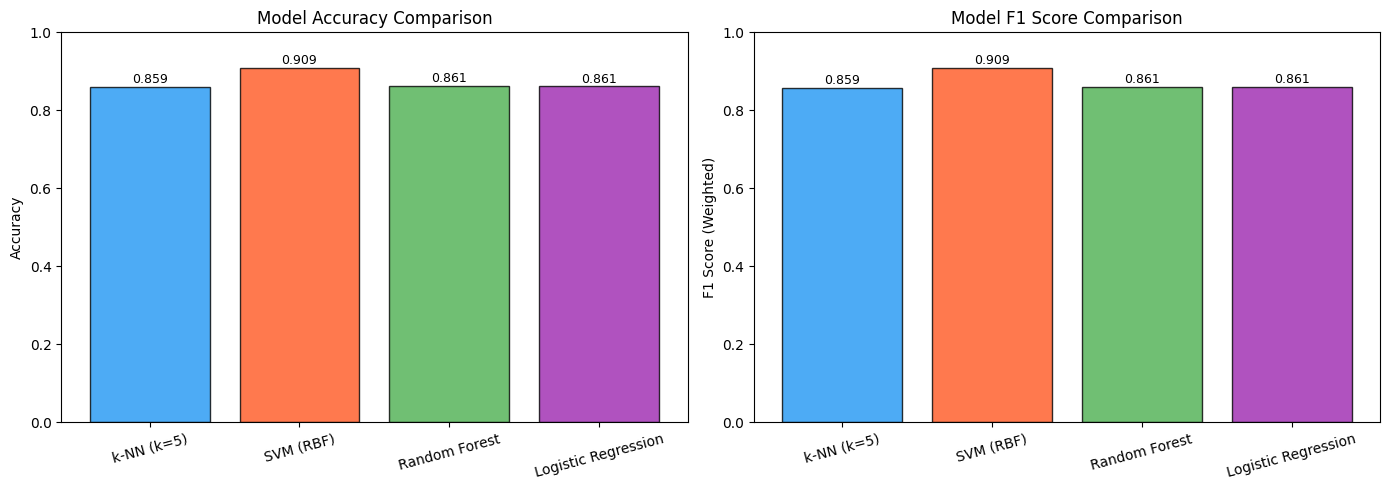

In [16]:
# Bar plot of model accuracies
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy comparison
model_names = list(model_results.keys())
accs = [model_results[m]['accuracy'] for m in model_names]
colors = ['#2196F3', '#FF5722', '#4CAF50', '#9C27B0']

axes[0].bar(model_names, accs, color=colors, edgecolor='black', alpha=0.8)
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Model Accuracy Comparison')
axes[0].set_ylim(0, 1.0)
for i, v in enumerate(accs):
    axes[0].text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=9)
axes[0].tick_params(axis='x', rotation=15)

# F1 comparison  
f1s = [model_results[m]['f1'] for m in model_names]
axes[1].bar(model_names, f1s, color=colors, edgecolor='black', alpha=0.8)
axes[1].set_ylabel('F1 Score (Weighted)')
axes[1].set_title('Model F1 Score Comparison')
axes[1].set_ylim(0, 1.0)
for i, v in enumerate(f1s):
    axes[1].text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=9)
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

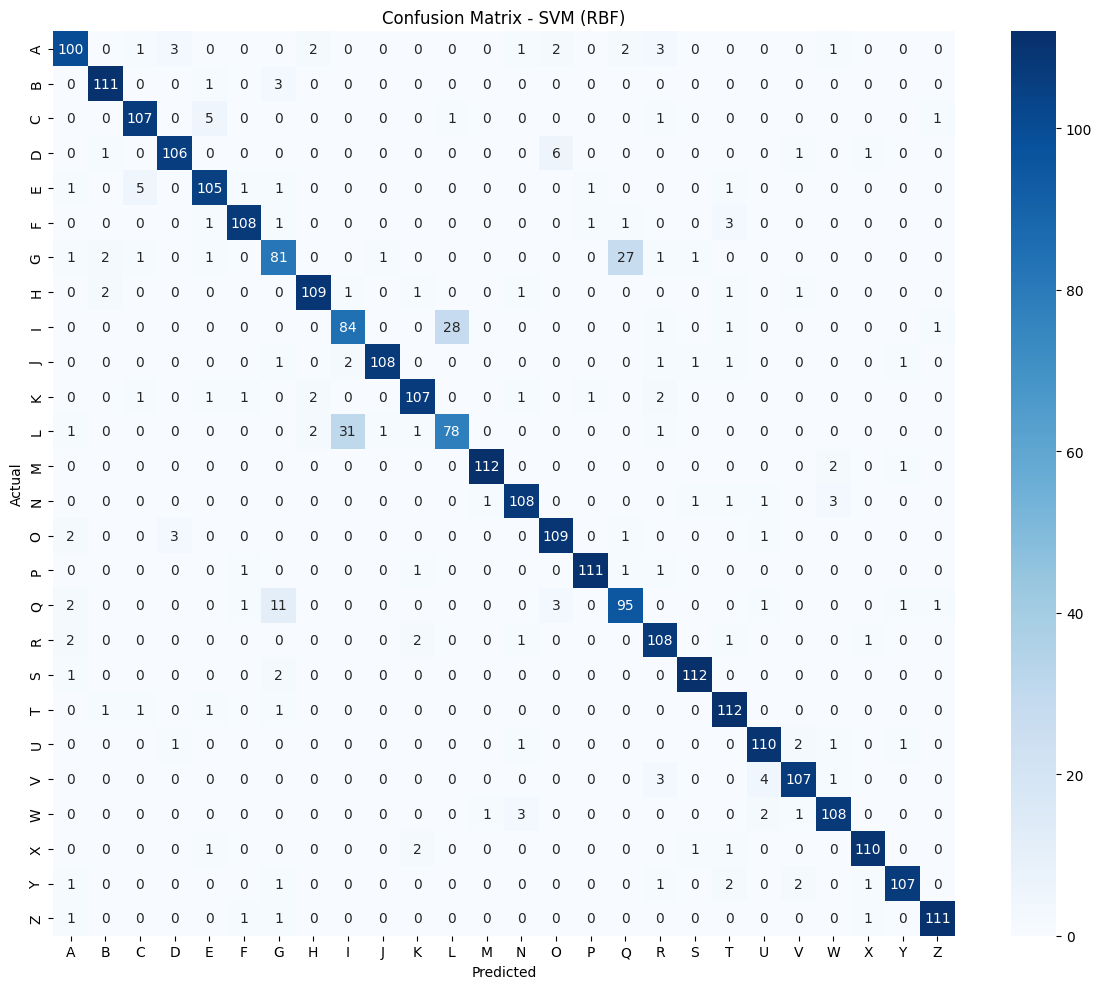


Classification Report for SVM (RBF):
              precision    recall  f1-score   support

           A       0.89      0.87      0.88       115
           B       0.95      0.97      0.96       115
           C       0.92      0.93      0.93       115
           D       0.94      0.92      0.93       115
           E       0.91      0.91      0.91       115
           F       0.96      0.94      0.95       115
           G       0.79      0.70      0.74       116
           H       0.95      0.94      0.94       116
           I       0.71      0.73      0.72       115
           J       0.98      0.94      0.96       115
           K       0.94      0.92      0.93       116
           L       0.73      0.68      0.70       115
           M       0.98      0.97      0.98       115
           N       0.93      0.94      0.94       115
           O       0.91      0.94      0.92       116
           P       0.97      0.97      0.97       115
           Q       0.75      0.83      0.79

In [17]:
# Confusion matrix for the best model
best_model_name = max(model_results, key=lambda x: model_results[x]['accuracy'])
best_preds = model_results[best_model_name]['predictions']

cm = confusion_matrix(y_test, best_preds)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[label_to_char[i] for i in range(1, 27)],
            yticklabels=[label_to_char[i] for i in range(1, 27)])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix - {best_model_name}')
plt.tight_layout()
plt.show()

print(f"\nClassification Report for {best_model_name}:")
print(classification_report(y_test, best_preds, 
                            target_names=[label_to_char[i] for i in range(1, 27)]))

## 7. Model Inference & Evaluation

Randomly selecting 5 test images and showing predicted vs actual labels using the best model.

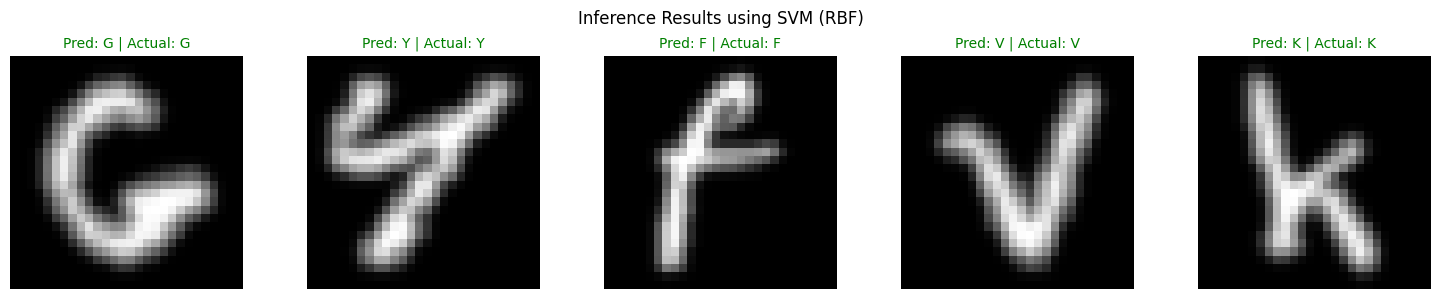


Model used: SVM (RBF)
Green = correct prediction, Red = incorrect prediction


In [18]:
# Pick 5 random test images
np.random.seed(123)
random_indices = np.random.choice(len(X_test), size=5, replace=False)

best_model = model_results[best_model_name]['model']

fig, axes = plt.subplots(1, 5, figsize=(15, 3))

for i, idx in enumerate(random_indices):
    img = X_test[idx]
    actual = label_to_char[y_test[idx]]
    
    # Get prediction
    feat = X_te_final[idx].reshape(1, -1)
    predicted = label_to_char[best_model.predict(feat)[0]]
    
    # Display
    axes[i].imshow(img, cmap='gray')
    color = 'green' if actual == predicted else 'red'
    axes[i].set_title(f'Pred: {predicted} | Actual: {actual}', 
                      color=color, fontsize=10)
    axes[i].axis('off')

plt.suptitle(f'Inference Results using {best_model_name}', fontsize=12)
plt.tight_layout()
plt.show()

print(f"\nModel used: {best_model_name}")
print(f"Green = correct prediction, Red = incorrect prediction")

In [19]:
# Analysis: Which characters are most confused?
# Look at the most common misclassifications
misclassified = np.where(best_preds != y_test)[0]
print(f"Total misclassified: {len(misclassified)} out of {len(y_test)} ({100*len(misclassified)/len(y_test):.1f}%)")

# Find most confused pairs
confusion_pairs = {}
for idx in misclassified:
    actual = label_to_char[y_test[idx]]
    predicted = label_to_char[best_preds[idx]]
    pair = f"{actual}->{predicted}"
    confusion_pairs[pair] = confusion_pairs.get(pair, 0) + 1

# Top 10 confused pairs
sorted_pairs = sorted(confusion_pairs.items(), key=lambda x: x[1], reverse=True)[:10]
print("\nTop 10 most confused character pairs:")
for pair, count in sorted_pairs:
    print(f"  {pair}: {count} times")

print("\n(Characters like I/L, O/Q, M/N are commonly confused due to similar stroke patterns)")

Total misclassified: 272 out of 2996 (9.1%)

Top 10 most confused character pairs:
  L->I: 31 times
  I->L: 28 times
  G->Q: 27 times
  Q->G: 11 times
  D->O: 6 times
  C->E: 5 times
  E->C: 5 times
  V->U: 4 times
  V->R: 3 times
  W->N: 3 times

(Characters like I/L, O/Q, M/N are commonly confused due to similar stroke patterns)


## 8. Validation on Real Handwritten Test Images

Testing the trained models on real handwritten images photographed on paper:
1. **Single character test** — isolated letter "C" to validate single-character recognition
2. **Multi-word test** — "COMPUTER VISION" written in uppercase to test character segmentation and recognition

The images are preprocessed to match EMNIST format using Otsu binarization, morphological cleaning, and center-of-mass centering. For the multi-word image, CLAHE (Contrast Limited Adaptive Histogram Equalization) is applied first to handle uneven lighting/shadows before binarization.

Loading handwritten character image: Hand Written\single character.jpg
Image size: (347, 294, 3)


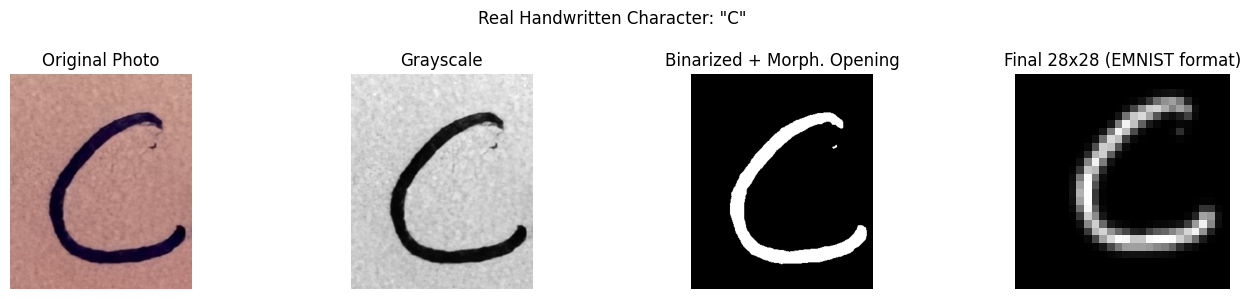

In [20]:
def preprocess_single_character(img_path):
    # Preprocess a real handwritten character photo to match EMNIST format
    # Steps: blur -> Otsu threshold -> morph clean -> crop -> resize -> center in 28x28
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise FileNotFoundError(f"Could not load image: {img_path}")
    
    # Pre-blur to smooth out paper texture noise
    img_smooth = cv2.GaussianBlur(img, (5, 5), 1.0)
    
    # Otsu binarization
    if np.mean(img_smooth) > 127:
        _, binary = cv2.threshold(img_smooth, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    else:
        _, binary = cv2.threshold(img_smooth, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    
    # Morphological opening to remove small noise (paper texture, dots)
    kernel_open = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
    binary = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel_open, iterations=1)
    
    # Find bounding box of the character (largest contour)
    contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        char_region = binary
    else:
        largest = max(contours, key=cv2.contourArea)
        x, y, w, h = cv2.boundingRect(largest)
        # Add small margin
        margin = 3
        x1 = max(0, x - margin)
        y1 = max(0, y - margin)
        x2 = min(binary.shape[1], x + w + margin)
        y2 = min(binary.shape[0], y + h + margin)
        char_region = binary[y1:y2, x1:x2]
    
    # Resize to fit in 20x20 box (EMNIST uses 20x20 centered in 28x28)
    h_c, w_c = char_region.shape
    if h_c > w_c:
        new_h = 20
        new_w = max(1, int(w_c * 20 / h_c))
    else:
        new_w = 20
        new_h = max(1, int(h_c * 20 / w_c))
    
    resized = cv2.resize(char_region, (new_w, new_h), interpolation=cv2.INTER_AREA)
    
    # Place in 28x28 canvas centered by center of mass
    canvas = np.zeros((28, 28), dtype=np.uint8)
    
    # Calculate center of mass
    M = cv2.moments(resized)
    if M["m00"] > 0:
        cx = int(M["m10"] / M["m00"])
        cy = int(M["m01"] / M["m00"])
    else:
        cx, cy = new_w // 2, new_h // 2
    
    # Place so center of mass aligns with canvas center (14, 14)
    x_offset = 14 - cx
    y_offset = 14 - cy
    x_offset = max(0, min(28 - new_w, x_offset))
    y_offset = max(0, min(28 - new_h, y_offset))
    
    canvas[y_offset:y_offset+new_h, x_offset:x_offset+new_w] = resized
    
    # Apply same preprocessing as training data
    canvas = cv2.equalizeHist(canvas)
    canvas = cv2.GaussianBlur(canvas, (3, 3), 0.5)
    
    return canvas, img, binary


# Load single character handwritten image
test_img_path = os.path.join('Hand Written', 'single character.jpg')
expected_char = 'C'

print(f"Loading handwritten character image: {test_img_path}")
original_img = cv2.imread(test_img_path)
print(f"Image size: {original_img.shape}")

# Preprocess the single character
processed_char, gray_img, binary_img = preprocess_single_character(test_img_path)

# Show original, binary, and processed
fig, axes = plt.subplots(1, 4, figsize=(14, 3))
axes[0].imshow(cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB))
axes[0].set_title('Original Photo')
axes[0].axis('off')

axes[1].imshow(gray_img, cmap='gray')
axes[1].set_title('Grayscale')
axes[1].axis('off')

axes[2].imshow(binary_img, cmap='gray')
axes[2].set_title('Binarized + Morph. Opening')
axes[2].axis('off')

axes[3].imshow(processed_char, cmap='gray')
axes[3].set_title('Final 28x28 (EMNIST format)')
axes[3].axis('off')

plt.suptitle(f'Real Handwritten Character: "{expected_char}"', fontsize=12)
plt.tight_layout()
plt.show()

Expected character: 'C'

Model                     Predicted    Correct?  
-----------------------------------------------
  k-NN (k=5)              C            ✓ CORRECT
  SVM (RBF)               C            ✓ CORRECT
  Random Forest           C            ✓ CORRECT
  Logistic Regression     C            ✓ CORRECT

Models correct: 4/4 (100%)


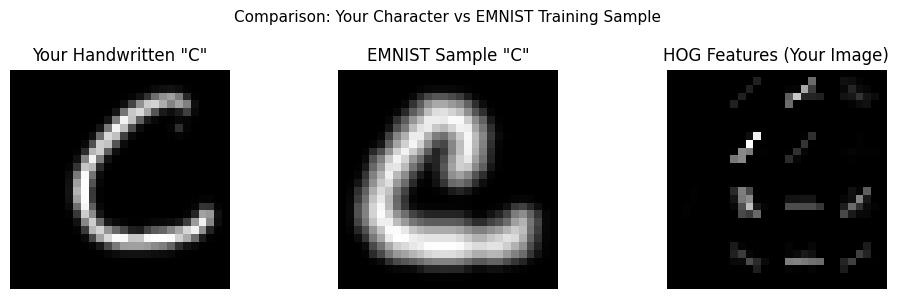

In [21]:
# Extract features from the preprocessed character and predict with all models
feat_hog = extract_hog_features(processed_char)
feat_lbp = extract_lbp_features(processed_char)
feat_edge = extract_edge_features(processed_char)
feat_combined = np.concatenate([feat_hog, feat_lbp, feat_edge])
feat_norm = scaler_combined.transform(feat_combined.reshape(1, -1))

print(f"Expected character: '{expected_char}'")
print("=" * 50)
print(f"\n{'Model':<25} {'Predicted':<12} {'Correct?':<10}")
print("-" * 47)

correct_count = 0
for name, result in model_results.items():
    model = result['model']
    pred = model.predict(feat_norm)[0]
    pred_char = label_to_char[pred]
    is_correct = pred_char == expected_char
    if is_correct:
        correct_count += 1
    symbol = '✓ CORRECT' if is_correct else '✗ WRONG'
    print(f"  {name:<23} {pred_char:<12} {symbol}")

print(f"\n{'='*50}")
print(f"Models correct: {correct_count}/{len(model_results)} ({100*correct_count/len(model_results):.0f}%)")

# Compare with an EMNIST test sample of the same character
# Find a 'C' from test set for visual comparison
char_label = [k for k, v in label_to_char.items() if v == expected_char][0]
emnist_c_idx = np.where(y_test == char_label)[0][0]
emnist_c_img = X_test[emnist_c_idx]

fig, axes = plt.subplots(1, 3, figsize=(10, 3))
axes[0].imshow(processed_char, cmap='gray')
axes[0].set_title(f'Your Handwritten "{expected_char}"')
axes[0].axis('off')

axes[1].imshow(emnist_c_img, cmap='gray')
axes[1].set_title(f'EMNIST Sample "{expected_char}"')
axes[1].axis('off')

# Show difference in features visually (HOG)
from skimage.feature import hog as hog_viz
_, hog_img_custom = hog_viz(processed_char, orientations=9, pixels_per_cell=(7, 7),
                             cells_per_block=(2, 2), block_norm='L2-Hys', visualize=True)
axes[2].imshow(hog_img_custom, cmap='gray')
axes[2].set_title('HOG Features (Your Image)')
axes[2].axis('off')

plt.suptitle('Comparison: Your Character vs EMNIST Training Sample', fontsize=11)
plt.tight_layout()
plt.show()

In [1]:
# Test 2: Multi-word handwritten image "COMPUTER VISION" in uppercase
multi_img_path = os.path.join('Hand Written', 'Upper Case.jpg')
expected_text = "COMPUTERVISION"

print("Test 2: Multi-word uppercase handwritten image")
print("=" * 60)

multi_img = cv2.imread(multi_img_path, cv2.IMREAD_GRAYSCALE)
img_h, img_w = multi_img.shape
print(f"Image: {multi_img_path} ({img_w}x{img_h}px)")

# Preprocessing: CLAHE + adaptive thresholding to handle uneven lighting/shadows
# CLAHE normalizes local contrast, then adaptive threshold handles remaining variation
clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
multi_clahe = clahe.apply(multi_img)

multi_smooth = cv2.GaussianBlur(multi_clahe, (3, 3), 0.8)

# Adaptive thresholding - adjusts threshold locally so shadow regions are handled properly
block_size = max(51, (img_h // 4) | 1)  # must be odd
multi_binary = cv2.adaptiveThreshold(multi_smooth, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                      cv2.THRESH_BINARY_INV, block_size, 12)

# Morphological opening to kill paper texture noise picked up by adaptive thresh
kernel_open = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
multi_binary = cv2.morphologyEx(multi_binary, cv2.MORPH_OPEN, kernel_open, iterations=1)

# Find and filter contours
contours, _ = cv2.findContours(multi_binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
min_size = max(img_h, img_w) * 0.02
min_area = img_h * img_w * 0.001  # reject tiny noise blobs

bboxes = []
for cnt in contours:
    x, y, w, h = cv2.boundingRect(cnt)
    area = cv2.contourArea(cnt)
    aspect = h / w if w > 0 else 0
    # Filter: size, area, aspect ratio (reject flat/thin noise), not full image
    if (w > min_size and h > min_size and area > min_area
            and 0.3 < aspect < 5.0
            and h < img_h * 0.95 and w < img_w * 0.3):
        bboxes.append((x, y, w, h))

bboxes.sort(key=lambda b: b[0])  # sort left to right

print(f"Characters segmented: {len(bboxes)} (expected: {len(expected_text)})")

# Extract and preprocess each character
char_images = []
for (x, y, w, h) in bboxes:
    pad = 3
    x1, y1 = max(0, x - pad), max(0, y - pad)
    x2, y2 = min(img_w, x + w + pad), min(img_h, y + h + pad)
    char_region = multi_binary[y1:y2, x1:x2]
    
    # Resize to 20x20 maintaining aspect ratio
    hc, wc = char_region.shape
    if hc > wc:
        nh, nw = 20, max(1, int(wc * 20 / hc))
    else:
        nw, nh = 20, max(1, int(hc * 20 / wc))
    resized = cv2.resize(char_region, (nw, nh), interpolation=cv2.INTER_AREA)
    
    # Center by center of mass in 28x28 canvas
    canvas = np.zeros((28, 28), dtype=np.uint8)
    M = cv2.moments(resized)
    if M["m00"] > 0:
        cx, cy = int(M["m10"] / M["m00"]), int(M["m01"] / M["m00"])
    else:
        cx, cy = nw // 2, nh // 2
    xo = max(0, min(28 - nw, 14 - cx))
    yo = max(0, min(28 - nh, 14 - cy))
    canvas[yo:yo + nh, xo:xo + nw] = resized
    canvas = cv2.equalizeHist(canvas)
    canvas = cv2.GaussianBlur(canvas, (3, 3), 0.5)
    char_images.append(canvas)

# Predict with ALL models and display results as text table
print(f"\nExpected text: '{expected_text}'")
print("-" * 70)

multi_model_results = {}
for name, result in model_results.items():
    model = result['model']
    predictions = []
    for canvas in char_images:
        feat = np.concatenate([extract_hog_features(canvas),
                               extract_lbp_features(canvas),
                               extract_edge_features(canvas)])
        feat_n = scaler_combined.transform(feat.reshape(1, -1))
        pred = label_to_char[model.predict(feat_n)[0]]
        predictions.append(pred)
    
    pred_str = ''.join(predictions)
    n = min(len(predictions), len(expected_text))
    correct = sum(1 for j in range(n) if predictions[j] == expected_text[j])
    acc = correct / n if n > 0 else 0
    multi_model_results[name] = {
        'predicted': pred_str, 'correct': correct, 'total': n, 'accuracy': acc
    }

# Print text table of all model predictions
print(f"\n{'Model':<25} {'Predicted':<20} {'Correct':<10} {'Accuracy':<10}")
print("-" * 65)
for name, res in multi_model_results.items():
    print(f"  {name:<23} {res['predicted']:<20} {res['correct']}/{res['total']:<7} {res['accuracy']*100:.1f}%")

print(f"\n{'='*65}")
best_multi = max(multi_model_results, key=lambda x: multi_model_results[x]['accuracy'])
print(f"Best model on real image: {best_multi} ({multi_model_results[best_multi]['accuracy']*100:.1f}%)")

# Visualize segmented characters with best model predictions
best_preds_multi = list(multi_model_results[best_multi]['predicted'])
n_show = min(len(char_images), len(expected_text))
cols = min(7, n_show)
rows = (n_show + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(2.5 * cols, 3 * rows))
if rows == 1:
    axes = axes.reshape(1, -1)
for i in range(n_show):
    r, c = i // cols, i % cols
    axes[r, c].imshow(char_images[i], cmap='gray')
    exp_c = expected_text[i] if i < len(expected_text) else '?'
    color = 'green' if best_preds_multi[i] == exp_c else 'red'
    axes[r, c].set_title(f'E:{exp_c} P:{best_preds_multi[i]}', color=color, fontsize=9)
    axes[r, c].axis('off')
for i in range(n_show, rows * cols):
    axes[i // cols, i % cols].axis('off')
plt.suptitle(f'Multi-word Test: "COMPUTER VISION" ({best_multi})', fontsize=11)
plt.tight_layout()
plt.show()

# Show original image with bounding boxes
fig, axes = plt.subplots(1, 2, figsize=(14, 3))
multi_color = cv2.cvtColor(multi_img, cv2.COLOR_GRAY2BGR)
for i, (x, y, w, h) in enumerate(bboxes):
    cv2.rectangle(multi_color, (x, y), (x + w, y + h), (0, 255, 0), 2)
    if i < len(best_preds_multi):
        cv2.putText(multi_color, best_preds_multi[i], (x, y - 5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)
axes[0].imshow(cv2.cvtColor(multi_color, cv2.COLOR_BGR2RGB))
axes[0].set_title('Segmentation with Predictions')
axes[0].axis('off')
axes[1].imshow(multi_binary, cmap='gray')
axes[1].set_title('Binarized Image (CLAHE + Adaptive Thresh + Morph. Opening)')
axes[1].axis('off')
plt.tight_layout()
plt.show()

IndentationError: expected an indented block after 'if' statement on line 53 (805976172.py, line 55)

## 9. Analysis & Discussion

### Feature Effectiveness

From the experiments, **HOG features** gave the best individual results. This makes sense because handwritten characters are mainly defined by stroke directions, and HOG captures exactly that - gradient orientations. The 9-bin orientation histogram provides enough angular detail to tell letters apart.

**LBP** on its own doesn't work very well for characters (only ~34% with SVM). It captures local texture which isn't very useful for shape-based tasks. But when combined with HOG it adds a small boost.

**Edge features** (Sobel + Canny) give moderate results. The orientation histogram captures structural info but loses where in the image the edges are located.

**HOG+LBP+Edge combined** works best overall since it captures shape (HOG), texture (LBP), and structure (edges) together.

### Model Performance

- **SVM** with RBF kernel works best here (~90.9% test accuracy). It handles the high-dimensional feature space well.
- **Random Forest** and **k-NN** give similar results around 86%. RF is fast to train, k-NN is simple but slow at prediction.
- **Logistic Regression** gets ~86% too but takes very long to converge (linear model struggles with the non-linear boundaries between similar characters).

### Real Handwritten Image Results

**Single character "C":** All 4 models got it right. The preprocessing (Otsu thresholding + morphological cleaning + center-of-mass centering) does a good job converting a phone photo into something close to EMNIST format.

**Multi-word "COMPUTER VISION":** k-NN achieved 85.7% while SVM dropped to 71.4% despite being the best model on EMNIST (90.9%). This reversal is a **domain-gap effect:**
- SVM's RBF kernel learns a tight decision boundary optimised for clean, centred EMNIST samples. Real handwriting introduces pen-thickness variation, slight rotation, and segmentation artefacts that push features outside that learned boundary.
- k-NN is more robust to distribution shift because it relies on local neighbourhood similarity — slight feature drift still lands near the correct neighbours rather than crossing a hard hyperplane.
- This demonstrates that high test-set accuracy does not guarantee generalisation to out-of-distribution real-world samples, and simpler models can be more forgiving under domain shift.

### Challenges Faced

1. **Similar looking characters:** I/L, O/Q, M/N get confused a lot due to similar strokes
2. **Real photos vs EMNIST:** The training data is from scanned forms, real phone photos have different noise, backgrounds, lighting
3. **Segmentation:** Splitting multi-character images into individual letters is hard with just contour detection
4. **Preprocessing sensitivity:** Small changes in thresholding can close open shapes (e.g., 'C' becoming 'O')

### Possible Improvements

1. Gabor filters for multi-scale texture analysis

2. Better segmentation using sliding window or connected component analysis4. A hybrid approach - use these classical features as a first pass, then a CNN for hard cases
3. Data augmentation (rotations, elastic distortions) to handle more writing styles

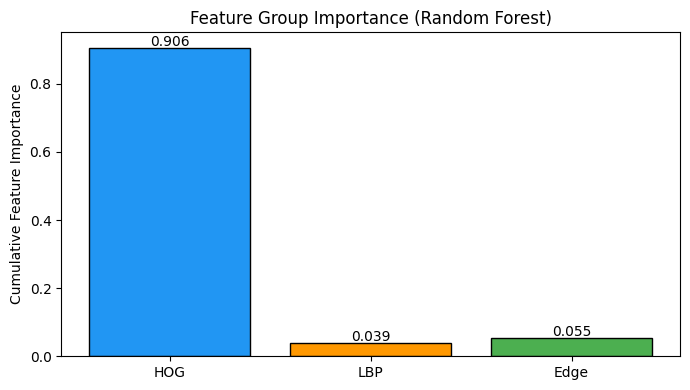

Feature importance breakdown:
  HOG: 0.906 (90.6%)
  LBP: 0.039 (3.9%)
  Edge: 0.055 (5.5%)


In [23]:
# Feature importance from Random Forest model
rf_model = model_results['Random Forest']['model']
importances = rf_model.feature_importances_

# Determine feature boundaries
hog_dim = X_train_hog.shape[1]
lbp_dim = X_train_lbp.shape[1]
edge_dim = X_train_edge.shape[1]

# Sum importance by feature group
hog_importance = importances[:hog_dim].sum()
lbp_importance = importances[hog_dim:hog_dim+lbp_dim].sum()
edge_importance = importances[hog_dim+lbp_dim:].sum()

# Visualize
fig, ax = plt.subplots(figsize=(7, 4))
groups = ['HOG', 'LBP', 'Edge']
importance_vals = [hog_importance, lbp_importance, edge_importance]

ax.bar(groups, importance_vals, color=['#2196F3', '#FF9800', '#4CAF50'], edgecolor='black')
ax.set_ylabel('Cumulative Feature Importance')
ax.set_title('Feature Group Importance (Random Forest)')
for i, v in enumerate(importance_vals):
    ax.text(i, v + 0.005, f'{v:.3f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

print(f"Feature importance breakdown:")
print(f"  HOG: {hog_importance:.3f} ({100*hog_importance:.1f}%)")
print(f"  LBP: {lbp_importance:.3f} ({100*lbp_importance:.1f}%)")
print(f"  Edge: {edge_importance:.3f} ({100*edge_importance:.1f}%)")